In [98]:
%load_ext cudf.pandas
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

The cudf.pandas extension is already loaded. To reload it, use:
  %reload_ext cudf.pandas


In [99]:
df = pd.read_csv("/kaggle/input/datasets/ashura369/late-delivery-prediction/APL_Logistics.csv", encoding='latin1')

In [100]:
with pd.option_context('display.max_columns', None):
    display(df.head(6))

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,Customer Country,Customer Fname,Customer Id,Customer Lname,Customer Segment,Customer State,Customer Street,Customer Zipcode,Department Id,Department Name,Latitude,Longitude,Market,Order City,Order Country,Order Customer Id,Order Item Discount,Order Item Discount Rate,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Region,Order State,Order Status,Product Name,Product Price,Shipping Mode
0,DEBIT,6,4,159.69,472.45,Late delivery,1,9,Cardio Equipment,Brownsville,EE. UU.,Richard,1,Hernandez,Consumer,TX,6303 Heather Plaza,78521.0,3,Footwear,25.953648,-97.507683,Pacific Asia,Mumbai,India,1,27.50,0.06,99.99,0.34,5,499.95,472.45,159.69,South Asia,Maharashtra,COMPLETE,Nike Men's Free 5.0+ Running Shoe,99.99,Standard Class
1,DEBIT,4,4,48.71,167.96,Shipping on time,0,29,Shop By Sport,Littleton,EE. UU.,Mary,2,Barrett,Consumer,CO,9526 Noble Embers Ridge,80126.0,5,Golf,38.375595,-104.726021,LATAM,San Pedro Sula,Honduras,2,31.99,0.16,39.99,0.29,5,199.95,167.96,48.71,Central America,Cortés,ON_HOLD,Under Armour Girls' Toddler Spine Surge Runni,39.99,Standard Class
2,DEBIT,4,4,87.36,181.99,Shipping on time,0,48,Water Sports,Littleton,EE. UU.,Mary,2,Barrett,Consumer,CO,9526 Noble Embers Ridge,80126.0,7,Fan Shop,38.375595,-104.726021,LATAM,San Pedro Sula,Honduras,2,18.00,0.09,199.99,0.48,1,199.99,181.99,87.36,Central America,Cortés,ON_HOLD,Pelican Sunstream 100 Kayak,199.99,Standard Class
3,DEBIT,6,4,-41.89,175.99,Late delivery,1,48,Water Sports,Littleton,EE. UU.,Mary,2,Barrett,Consumer,CO,9526 Noble Embers Ridge,80126.0,7,Fan Shop,38.375595,-104.726021,USCA,New York City,Estados Unidos,2,24.00,0.12,199.99,-0.24,1,199.99,175.99,-41.89,East of USA,Nueva York,COMPLETE,Pelican Sunstream 100 Kayak,199.99,Standard Class
4,DEBIT,6,4,10.00,40.00,Late delivery,1,24,Women's Apparel,Littleton,EE. UU.,Mary,2,Barrett,Consumer,CO,9526 Noble Embers Ridge,80126.0,5,Golf,38.375595,-104.726021,USCA,New York City,Estados Unidos,2,10.00,0.20,50.00,0.25,1,50.00,40.00,10.00,East of USA,Nueva York,COMPLETE,Nike Men's Dri-FIT Victory Golf Polo,50.00,Standard Class
5,DEBIT,6,4,105.63,290.98,Late delivery,1,43,Camping & Hiking,Littleton,EE. UU.,Mary,2,Barrett,Consumer,CO,9526 Noble Embers Ridge,80126.0,7,Fan Shop,38.375595,-104.726021,USCA,New York City,Estados Unidos,2,9.00,0.03,299.98,0.36,1,299.98,290.98,105.63,East of USA,Nueva York,COMPLETE,Diamondback Women's Serene Classic Comfort Bi,299.98,Standard Class


In [101]:
# checking for null values
print(df.isna().sum())

Type                             0
Days for shipping (real)         0
Days for shipment (scheduled)    0
Benefit per order                0
Sales per customer               0
Delivery Status                  0
Late_delivery_risk               0
Category Id                      0
Category Name                    0
Customer City                    0
Customer Country                 0
Customer Fname                   0
Customer Id                      0
Customer Lname                   8
Customer Segment                 0
Customer State                   0
Customer Street                  0
Customer Zipcode                 3
Department Id                    0
Department Name                  0
Latitude                         0
Longitude                        0
Market                           0
Order City                       0
Order Country                    0
Order Customer Id                0
Order Item Discount              0
Order Item Discount Rate         0
Order Item Product P

In [102]:
# checking for total samples and features
print(f"TOTAL SAMPLES : {df.shape[0]}\nTOTAL FEATURES : {df.shape[1]}")

TOTAL SAMPLES : 180519
TOTAL FEATURES : 40


In [103]:
# printing the column names, data type they contain, total number of unique values, and the content they hold (unique values only)

context = [df[col].unique().tolist() for col in df.columns]

# making a dataset for entire overview
overview = pd.DataFrame({
    'DTYPES' : df.dtypes,
    'NO. OF UNIQUE VALUES' : df.nunique(),
    'CONTENT' : context
})

In [104]:
with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.max_colwidth', None):
    display(overview)

,DTYPES,NO. OF UNIQUE VALUES,CONTENT
Type,object,4,"[DEBIT, PAYMENT, TRANSFER, CASH]"
Days for shipping (real),int64,7,"[6, 4, 3, 0, 5, 2, 1]"
Days for shipment (scheduled),int64,4,"[4, 0, 1, 2]"
Benefit per order,float64,21998,"[159.69, 48.71, 87.36, -41.89, 10.0, 105.63, 64.1, 22.67, 3.52, 40.34, -131.7, 34.5, 10.8, -42.61, 27.41, -140.73, 11.4, 46.51, -274.39, 83.69, 108.23, 11.25, 66.62, 43.16, 2.99, 39.36, 117.58, 111.73, 76.99, -445.21, 17.22, 33.25, -70.36, -41.77, 48.66, 59.39, 26.99, 3.37, 23.23, 11.88, -21.0, -119.92, 34.29, 78.91, 51.16, 53.55, 47.92, 21.77, 27.29, 29.25, 75.2, 215.98, 56.83, 25.48, 143.99, 111.04, 19.07, 91.52, 0.0, 46.97, 45.35, -63.64, 38.52, 50.38, 36.96, 45.82, 42.25, 97.49, 78.74, 7.43, 34.13, -250.1, 153.43, 54.28, 49.72, 2.79, 74.79, 1.12, 41.98, 132.29, 72.03, 52.38, 125.73, -17.4, 165.99, 24.53, 109.43, 89.3, 180.58, 18.41, 20.16, 89.24, 30.0, 4.18, 120.11, 63.45, 44.8, -43.76, 25.05, 45.0, ...]"
Sales per customer,float64,2927,"[472.45, 167.96, 181.99, 175.99, 40.0, 290.98, 142.44, 83.97, 351.98, 98.38, 84.97, 74.99, 24.35, 94.5, 191.99, 189.99, 98.96, 391.98, 269.98, 263.98, 90.0, 141.75, 107.89, 248.98, 245.98, 235.16, 232.76, 245.96, 251.96, 49.19, 95.98, 56.99, 143.98, 134.98, 119.95, 18.74, 70.38, 118.78, 84.0, 139.44, 97.96, 208.77, 106.59, 254.98, 145.21, 197.92, 90.96, 97.49, 160.0, 479.95, 195.95, 91.0, 299.97, 236.25, 116.99, 161.97, 82.97, 81.97, 209.92, 127.45, 129.99, 299.98, 224.99, 99.0, 169.98, 136.5, 374.96, 464.95, 113.09, 110.49, 232.41, 37.49, 149.94, 377.98, 147.0, 145.5, 371.98, 347.98, 335.98, 331.98, 52.19, 287.98, 190.0, 419.96, 197.98, 40.02, 126.0, 194.0, 200.0, 104.45, 272.98, 135.0, 159.99, 179.99, 237.41, 130.45, 24.24, 169.96, 149.99, 284.99, ...]"
Delivery Status,object,4,"[Late delivery, Shipping on time, Advance shipping, Shipping canceled]"
Late_delivery_risk,int64,2,"[1, 0]"
Category Id,int64,51,"[9, 29, 48, 24, 43, 46, 45, 17, 13, 18, 40, 11, 41, 3, 35, 30, 36, 7, 33, 37, 12, 32, 26, 16, 5, 6, 38, 10, 2, 34, 44, 31, 4, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76]"
Category Name,object,50,"[Cardio Equipment, Shop By Sport, Water Sports, Women's Apparel, Camping & Hiking, Indoor/Outdoor Games, Fishing, Cleats, Electronics, Men's Footwear, Accessories, Fitness Accessories, Trade-In, Baseball & Softball, Golf Gloves, Men's Golf Clubs, Golf Balls, Hockey, Golf Shoes, Boxing & MMA, Golf Apparel, Girls' Apparel, As Seen on TV!, Lacrosse, Tennis & Racquet, Kids' Golf Clubs, Strength Training, Soccer, Golf Bags & Carts, Hunting & Shooting, Women's Golf Clubs, Basketball, Books , Baby , CDs , Cameras , Children's Clothing, Computers, Consumer Electronics, Crafts, DVDs, Garden, Health and Beauty, Men's Clothing, Music, Pet Supplies, Sporting Goods, Toys, Video Games, Women's Clothing]"
Customer City,object,563,"[Brownsville, Littleton, Caguas, San Marcos, Passaic, Lawrence, Stafford, San Antonio, Pico Rivera, Fontana, Taylor, Martinez, West New York, North Bergen, San Juan, Peoria, Glenview, Longview, Fort Worth, Albuquerque, Norfolk, Oceanside, Opelousas, Long Beach, Brooklyn, Duluth, Napa, Denver, Freeport, Strongsville, San Bernardino, Chicago, Roswell, Phoenix, Baltimore, Sunnyvale, Webster, Princeton, Los Angeles, Philadelphia, Vista, Jacksonville, Parkville, Knoxville, Ithaca, Tampa, Atlanta, Escondido, Spring, Annapolis, Hyattsville, Las Vegas, Dorchester Center, Broomfield, Saint Paul, Bronx, Beaverton, Middletown, Bellflower, West Covina, La Crosse, Ogden, Cincinnati, Bend, Oxnard, Amarillo, Augusta, Aurora, Methuen, Lynn, Broken Arrow, San Diego, Opa Locka, Dayton, Hanover, Colton, Union, Richmond, Hollywood, Brandon, Citrus Heights, Corona, Hialeah, Rio Rancho, Antioch, Florissant, Columbus, Chino, Lombard, Dundalk, Irwin, Hayward, Lindenhurst, Louisville, Portland, Gaithersburg, Modesto, Dearborn, Lancaster, Pompano Beach, ...]"


### Observation

In this step, we drop columns that are not useful for our descriptive analysis and visualization. Removing these columns helps reduce memory usage, declutters the DataFrame, and makes it easier to display tables and plots.

**The columns are to be removed based on the following categories:**

1. **Personally Identifiable Information (PII) & Privacy:**
   * `Customer Fname` & `Customer Lname`: Customer names are unique to individuals and do not provide any aggregatable business insights.
   * `Customer Street`: Street-level addresses are too granular for high-level geographic charts.

2. **Database Keys & Unique Identifiers (IDs):**
   * `Customer Id`, `Order Customer Id`, `Category Id`, and `Department Id`: These are database keys used for table joins. For visualization, the descriptive names (like `Category Name` or `Department Name`) are used instead of numeric IDs.

3. **Redundant Columns:**
   * `Order Item Product Price`: This is redundant since we already have `Product Price`.
   * `Customer Zipcode`: Zip codes have too many unique values to visualize effectively on charts (we use broader regions like `Customer State` or `Customer City` instead).

4. **Excluded Metrics (Optional):**
   * `Order Profit Per Order`: Excluded from this specific visualization subset because we already have a similar column to this.

In [105]:
df = df.drop(columns=['Days for shipping (real)','Benefit per order','Sales per customer','Category Id','Customer Fname','Order Status','Customer Lname','Customer Id','Customer Street','Department Id','Order Customer Id','Order Item Product Price','Order Profit Per Order'])

In [106]:
print(df.columns)
print('\nREMAINING COLUMNS : ', len(df.columns))
print(f"TOTAL NO. OF COLUMNS REMOVED : {40 - 27}")

Index(['Type', 'Days for shipment (scheduled)', 'Delivery Status',
       'Late_delivery_risk', 'Category Name', 'Customer City',
       'Customer Country', 'Customer Segment', 'Customer State',
       'Customer Zipcode', 'Department Name', 'Latitude', 'Longitude',
       'Market', 'Order City', 'Order Country', 'Order Item Discount',
       'Order Item Discount Rate', 'Order Item Profit Ratio',
       'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Region',
       'Order State', 'Product Name', 'Product Price', 'Shipping Mode'],
      dtype='object')

REMAINING COLUMNS :  27
TOTAL NO. OF COLUMNS REMOVED : 13


In [107]:
df = df.dropna()

#### Changing The Columns Names For Better Understanding

In [108]:
df = df.rename(columns={
    'Type' : 'Payment Method',
    'Late_delivery_risk' : 'Late Delivery ?',
    'Category Name' : 'Product Category',
    'Sales' : 'Total Sales',
    'Order Item Total' : 'Price After Discount'
})

#### Making Another Separate Data Type For `int` And `float`

In [109]:
int_df = df.select_dtypes([int, float])
int_df.drop(columns=['Late Delivery ?','Customer Zipcode','Latitude','Longitude'], inplace=True)                # dropping output feature
int_df.sample(6)

,Days for shipment (scheduled),Order Item Discount,Order Item Discount Rate,Order Item Profit Ratio,Order Item Quantity,Total Sales,Price After Discount,Product Price
107259,4,35.99,0.12,0.33,5,299.95,263.96,59.99
30061,2,5.00,0.05,0.35,2,100.00,95.00,50.00
8948,2,8.00,0.04,0.06,1,199.99,191.99,199.99
94758,4,20.00,0.05,0.09,1,399.98,379.98,399.98
97426,4,22.00,0.06,0.27,1,399.98,377.98,399.98
35331,2,1.60,0.01,0.26,4,159.96,158.36,39.99


#### Checking For Distribution Of Data For Each Column

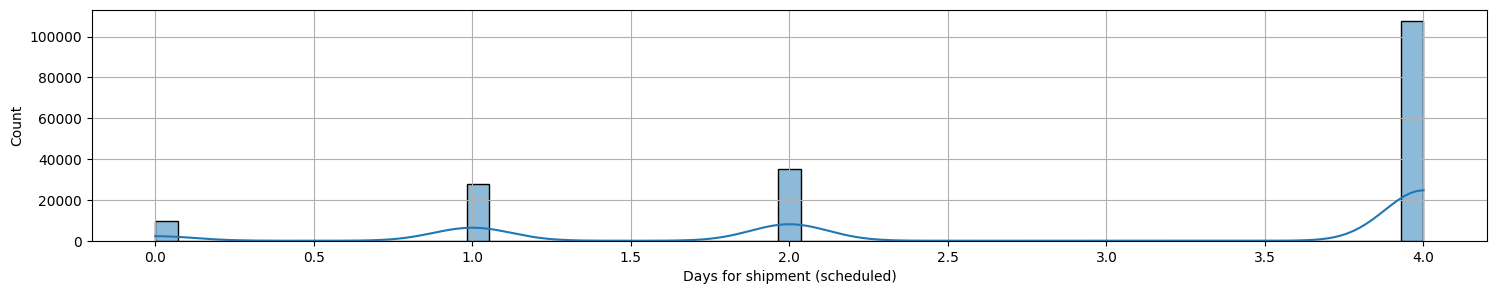

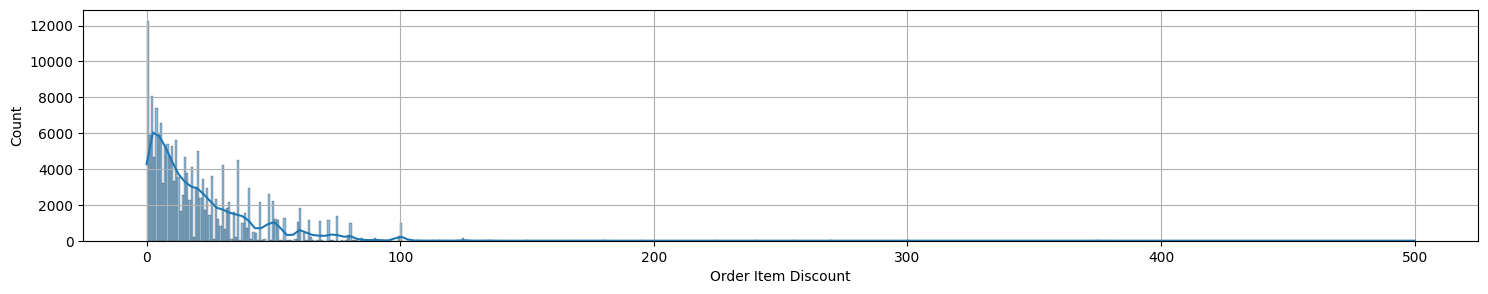

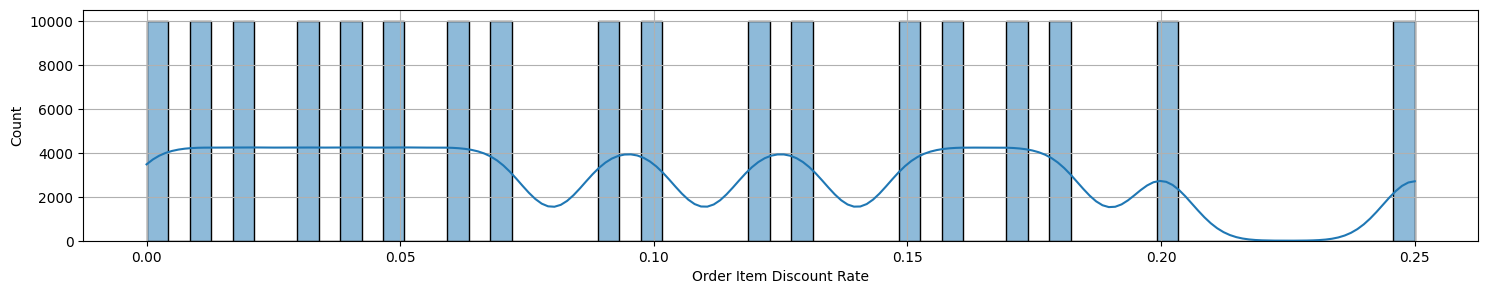

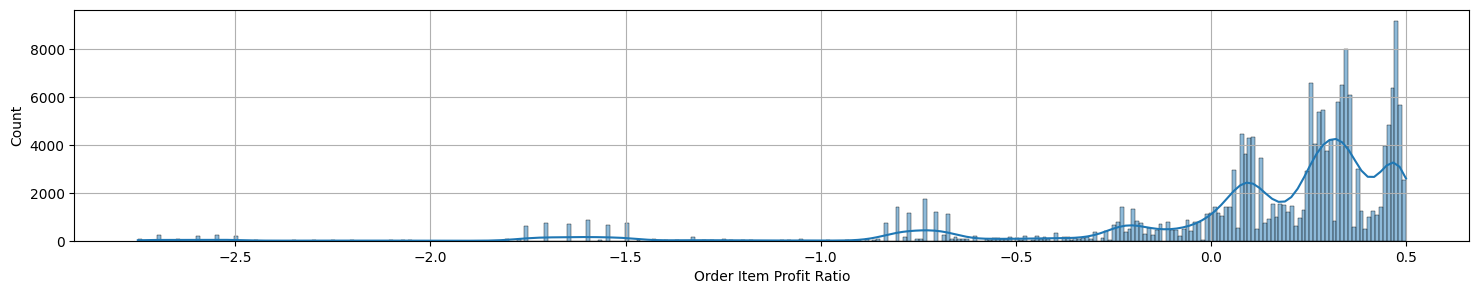

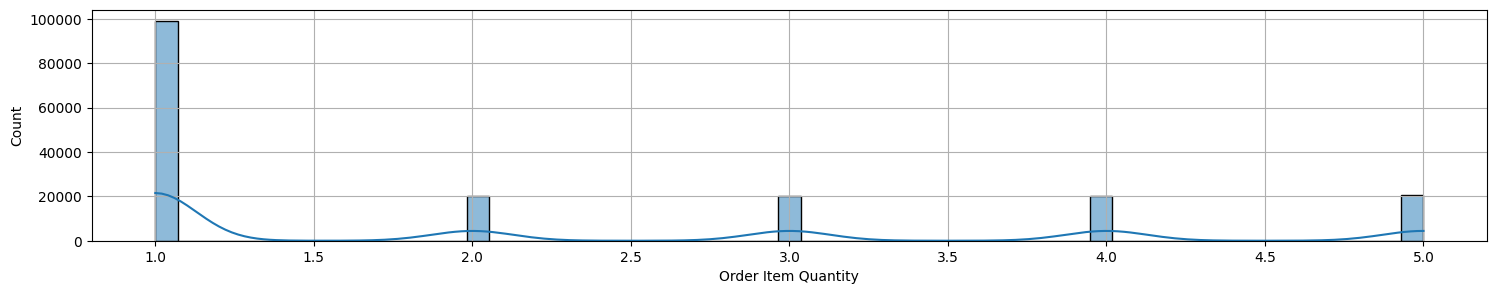

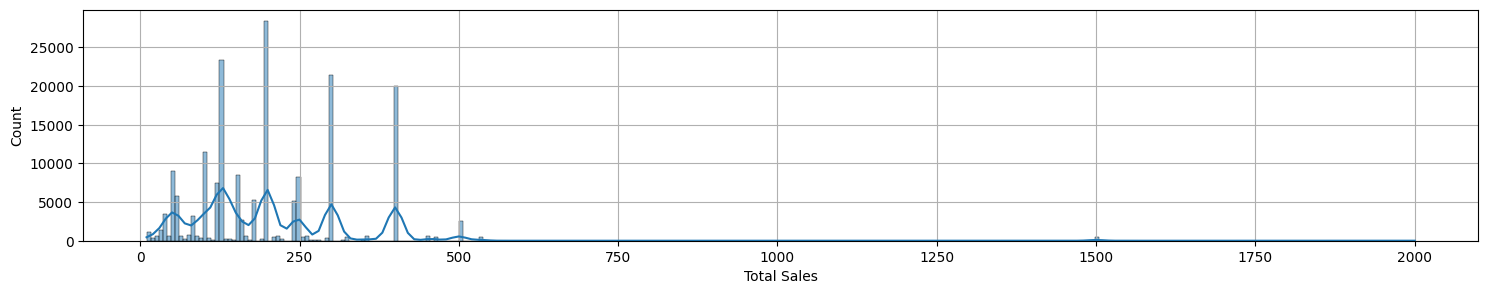

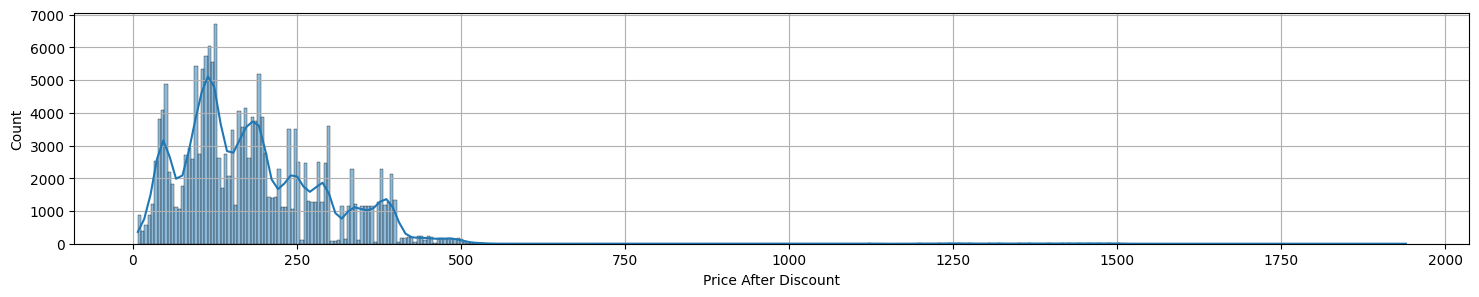

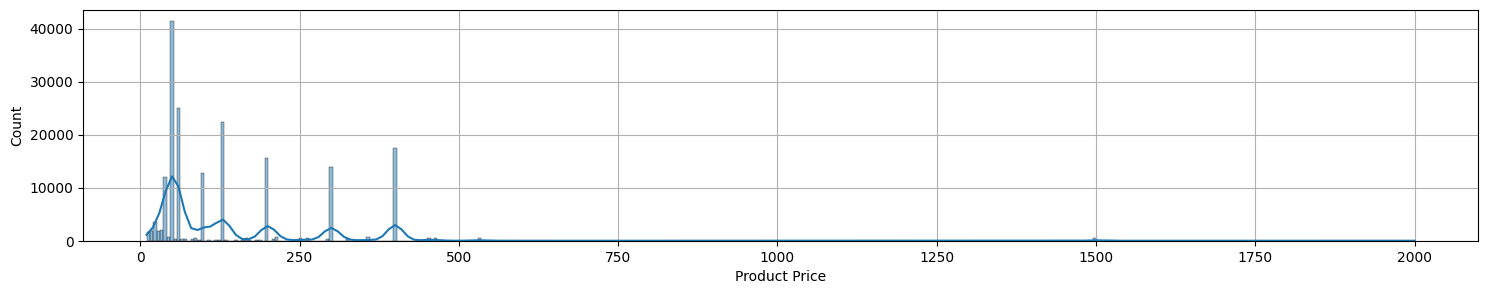

In [110]:
for col in int_df.columns:
    plt.figure(figsize=(18,3))
    sns.histplot(x=int_df[col], kde=True)
    plt.grid(True)
plt.show()

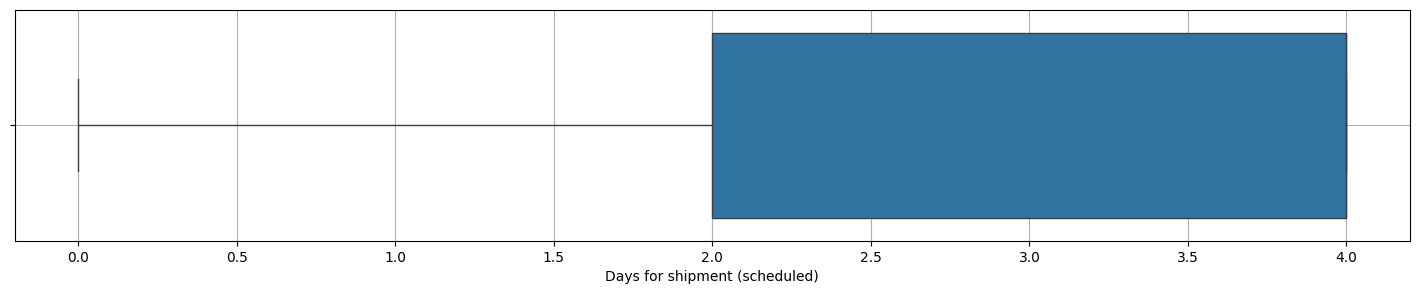

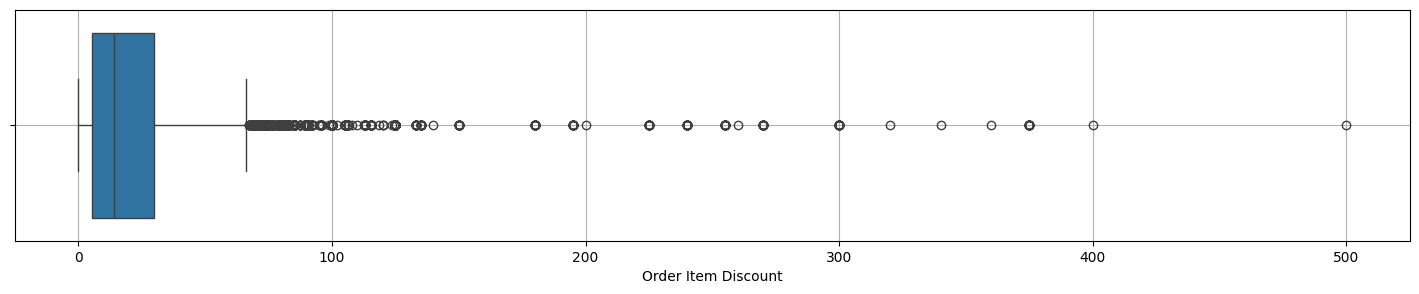

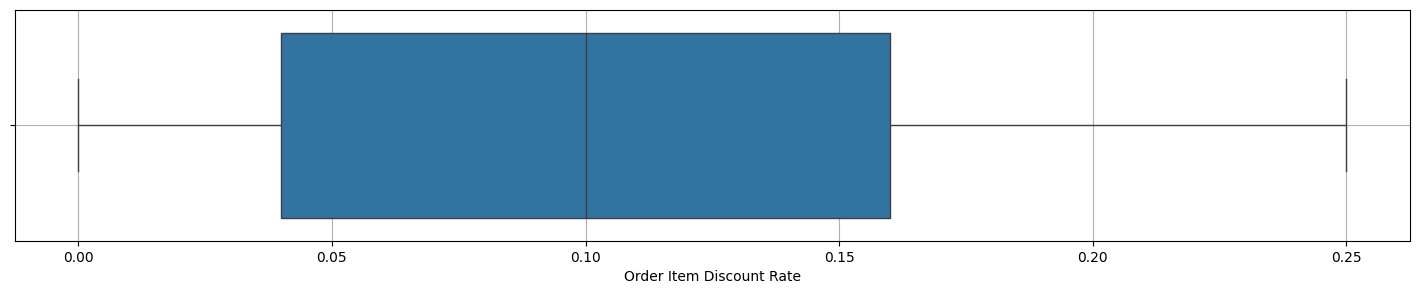

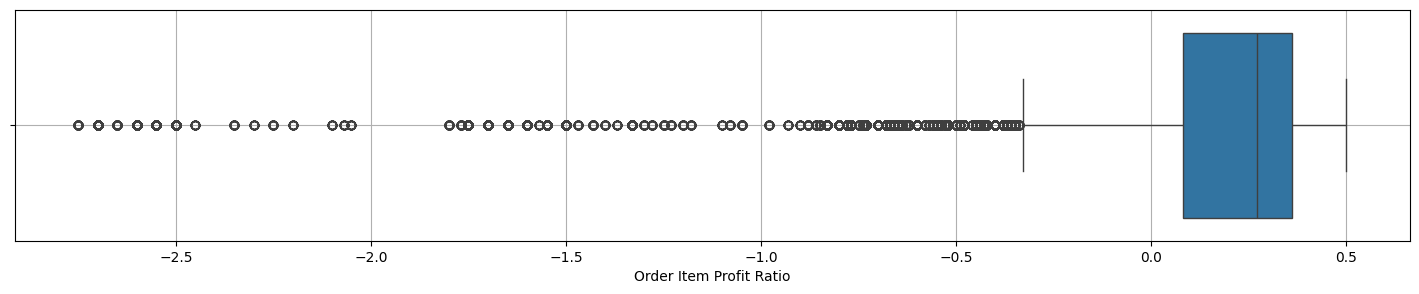

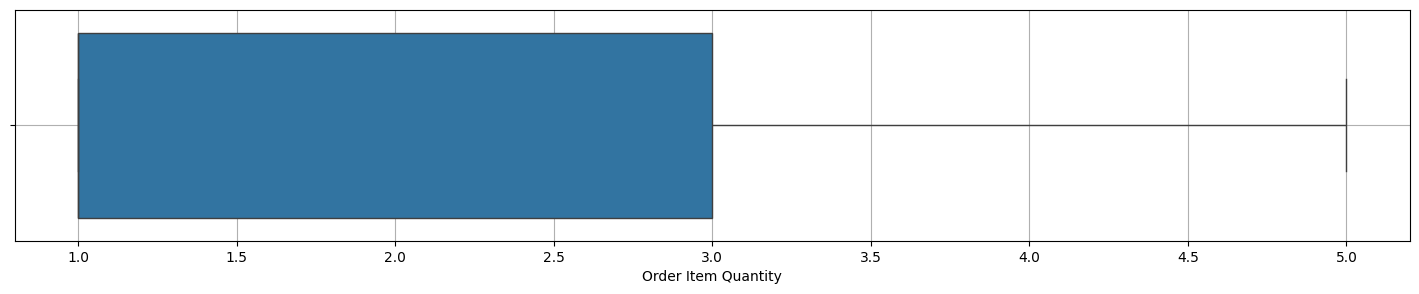

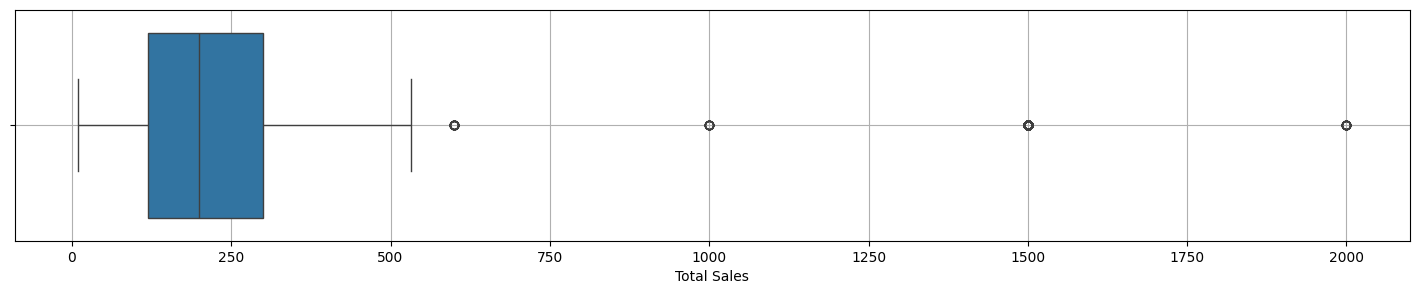

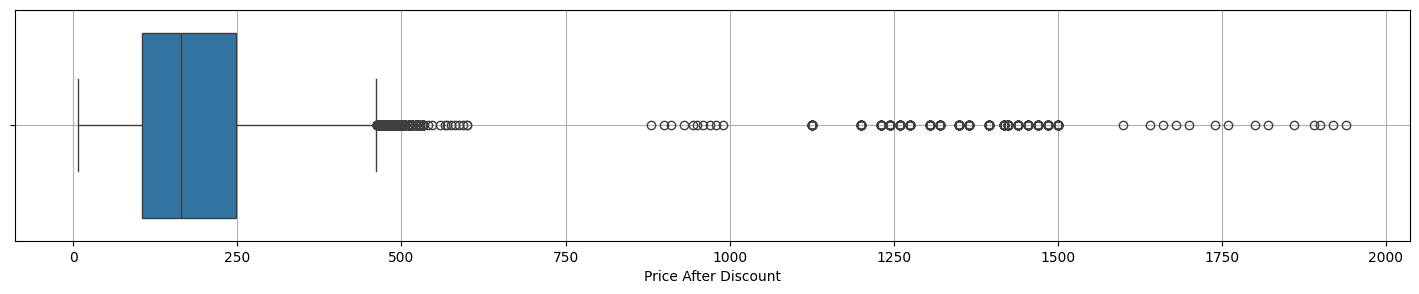

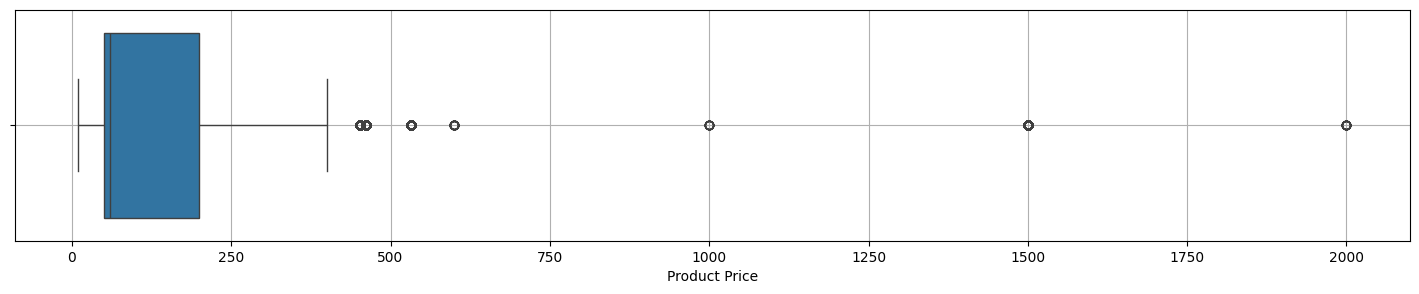

In [111]:
for col in int_df.columns:
    plt.figure(figsize=(18,3))
    sns.boxplot(x=int_df[col])
    plt.grid(True)
plt.show()

## **OBSERVATION**
- Outlier detected in `Price After Discount`, and `Produce Price`
    - We should keep the outliers as it is because, we are going to use Tree Baed Models, which tend to perform better even on outlier data.

#### Checking The Outlier Features

In [112]:
int_df[['Price After Discount', 'Product Price']].describe()

,Price After Discount,Product Price
count,180516.000000,180516.000000
mean,183.107722,141.231294
std,120.043870,139.732275
min,7.490000,9.990000
25%,104.380000,50.000000
50%,163.990000,59.990000
75%,247.400000,199.990000
max,1939.990000,1999.990000


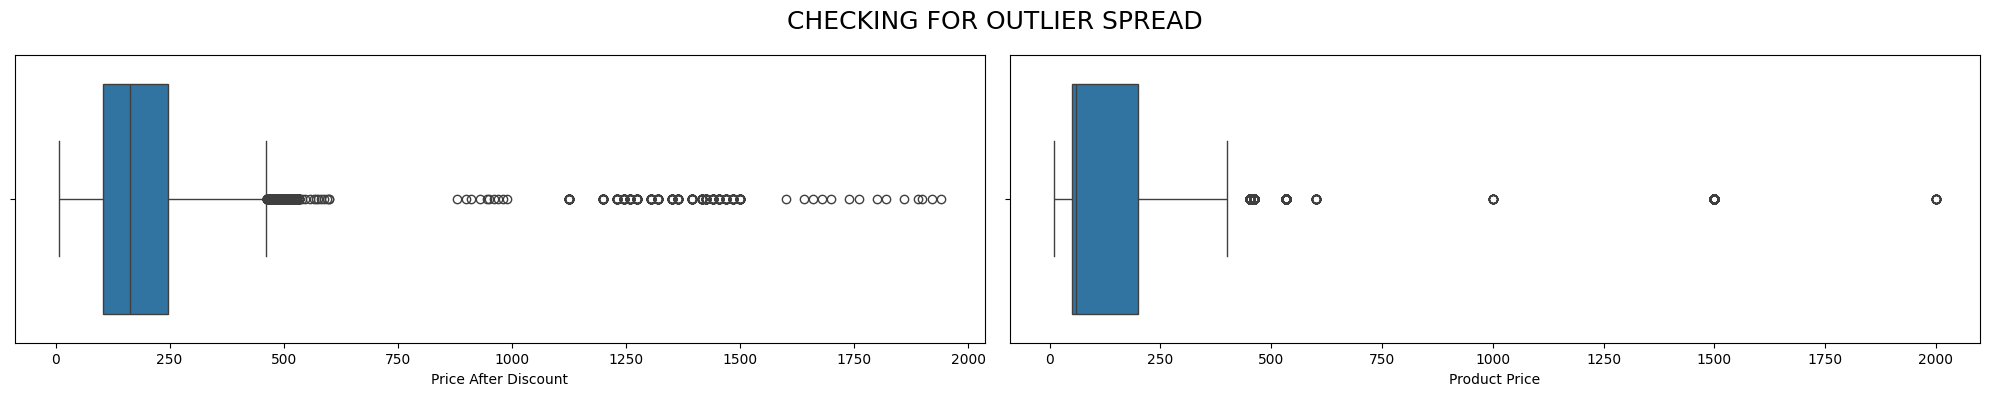

In [113]:
plt.figure(figsize=(20,4))
plt.subplot(1,2,1)
sns.boxplot(x=int_df['Price After Discount'])
plt.subplot(1,2,2)
sns.boxplot(x=int_df['Product Price'])

plt.suptitle('CHECKING FOR OUTLIER SPREAD', fontsize=18)
plt.tight_layout()
plt.show()

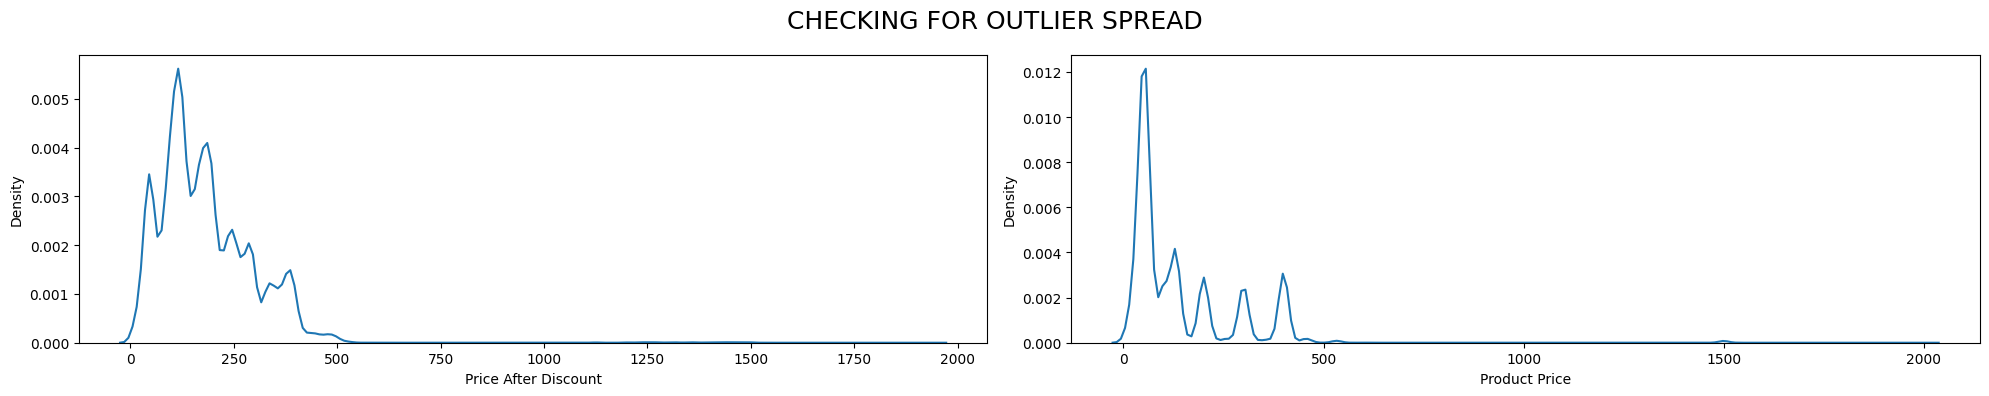

In [114]:
plt.figure(figsize=(20,4))
plt.subplot(1,2,1)
sns.kdeplot(x=int_df['Price After Discount'])
plt.subplot(1,2,2)
sns.kdeplot(x=int_df['Product Price'])

plt.suptitle('CHECKING FOR OUTLIER SPREAD', fontsize=18)
plt.tight_layout()
plt.show()

### Checking For Imbalanced Dataset

In [115]:
print(np.round(df['Late Delivery ?'].value_counts(normalize=True) * 100, 2))

Late Delivery ?
1    54.83
0    45.17
Name: proportion, dtype: float64


### Separating All Categorical Features For Encoding

In [116]:
cat_df = df.select_dtypes(exclude=[int,float,bool])

In [117]:
cat_df.head(5)

,Payment Method,Delivery Status,Product Category,Customer City,Customer Country,Customer Segment,Customer State,Department Name,Market,Order City,Order Country,Order Region,Order State,Product Name,Shipping Mode
0,DEBIT,Late delivery,Cardio Equipment,Brownsville,EE. UU.,Consumer,TX,Footwear,Pacific Asia,Mumbai,India,South Asia,Maharashtra,Nike Men's Free 5.0+ Running Shoe,Standard Class
1,DEBIT,Shipping on time,Shop By Sport,Littleton,EE. UU.,Consumer,CO,Golf,LATAM,San Pedro Sula,Honduras,Central America,Cortés,Under Armour Girls' Toddler Spine Surge Runni,Standard Class
2,DEBIT,Shipping on time,Water Sports,Littleton,EE. UU.,Consumer,CO,Fan Shop,LATAM,San Pedro Sula,Honduras,Central America,Cortés,Pelican Sunstream 100 Kayak,Standard Class
3,DEBIT,Late delivery,Water Sports,Littleton,EE. UU.,Consumer,CO,Fan Shop,USCA,New York City,Estados Unidos,East of USA,Nueva York,Pelican Sunstream 100 Kayak,Standard Class
4,DEBIT,Late delivery,Women's Apparel,Littleton,EE. UU.,Consumer,CO,Golf,USCA,New York City,Estados Unidos,East of USA,Nueva York,Nike Men's Dri-FIT Victory Golf Polo,Standard Class


#### Applying `TargetEncoder`

In [118]:
from sklearn.model_selection import train_test_split as ttt
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import TargetEncoder
import optuna

In [119]:
encoder = TargetEncoder(smooth='auto', cv=5, random_state=42)

In [120]:
x = df.drop(columns='Late Delivery ?')
y = df['Late Delivery ?']

In [121]:
cat_df_transformed = encoder.fit_transform(cat_df,y)

In [122]:
print(cat_df_transformed.shape)
print()
print(cat_df.columns)
print()
print(cat_df_transformed)

(180516, 15)

Index(['Payment Method', 'Delivery Status', 'Product Category',
       'Customer City', 'Customer Country', 'Customer Segment',
       'Customer State', 'Department Name', 'Market', 'Order City',
       'Order Country', 'Order Region', 'Order State', 'Product Name',
       'Shipping Mode'],
      dtype='object')

[[0.57080236 1.         0.54264087 ... 0.56640845 0.54260607 0.38170805]
 [0.57128388 0.         0.5501528  ... 0.52575246 0.55072605 0.3803526 ]
 [0.57369933 0.         0.5499758  ... 0.52163    0.54983497 0.38044106]
 ...
 [0.57162639 0.         0.55630989 ... 0.57628101 0.55630989 0.38046121]
 [0.57447817 0.         0.55347635 ... 0.55907465 0.55347635 0.38044106]
 [0.56665065 1.         0.55098525 ... 0.56183579 0.55098525 0.45887099]]


#### Replacing The Original Features In x With The New Encoded Features

In [125]:
x.isna().sum().sum()

np.int64(0)

In [126]:
x[cat_df.columns] = cat_df_transformed

In [127]:
with pd.option_context('display.max_columns', None):
    display(x.head(6))

,Payment Method,Days for shipment (scheduled),Delivery Status,Product Category,Customer City,Customer Country,Customer Segment,Customer State,Customer Zipcode,Department Name,Latitude,Longitude,Market,Order City,Order Country,Order Item Discount,Order Item Discount Rate,Order Item Profit Ratio,Order Item Quantity,Total Sales,Price After Discount,Order Region,Order State,Product Name,Product Price,Shipping Mode
0,0.570802,4,1.0,0.542641,0.490096,0.548588,0.547354,0.548218,78521.0,0.545283,25.953648,-97.507683,0.551244,0.602556,0.564650,27.50,0.06,0.34,5,499.95,472.45,0.564851,0.566408,0.542606,99.99,0.381708
1,0.571284,4,0.0,0.550153,0.571238,0.548393,0.547888,0.502329,80126.0,0.547346,38.375595,-104.726021,0.543118,0.546395,0.525113,31.99,0.16,0.29,5,199.95,167.96,0.548001,0.525752,0.550726,39.99,0.380353
2,0.573699,4,0.0,0.549976,0.559530,0.548894,0.547688,0.498375,80126.0,0.547579,38.375595,-104.726021,0.541918,0.540147,0.526860,18.00,0.09,0.48,1,199.99,181.99,0.546462,0.521630,0.549835,199.99,0.380441
3,0.571284,4,1.0,0.546523,0.571238,0.548393,0.547888,0.502329,80126.0,0.547489,38.375595,-104.726021,0.546952,0.570103,0.549281,24.00,0.12,-0.24,1,199.99,175.99,0.556709,0.577529,0.546275,199.99,0.380353
4,0.573699,4,1.0,0.545520,0.559530,0.548894,0.547688,0.498375,80126.0,0.548671,38.375595,-104.726021,0.550235,0.575056,0.553292,10.00,0.20,0.25,1,50.00,40.00,0.561553,0.581886,0.545520,50.00,0.380441
5,0.570802,4,1.0,0.544601,0.583763,0.548588,0.547354,0.515817,80126.0,0.547554,38.375595,-104.726021,0.547641,0.573673,0.549579,9.00,0.03,0.36,1,299.98,290.98,0.556992,0.578626,0.544601,299.98,0.381708


In [128]:
x_train, x_test, y_train, y_test = ttt(x,y,test_size=0.3,random_state=42)

#### Making Optuna Model

In [129]:
from sklearn.metrics import roc_auc_score
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

In [132]:
from sklearn.metrics import accuracy_score

def objective(trial):
    # choosing the model
    classifier_name = trial.suggest_categorical('classifier', ['XGBoost', 'RandomForest', 'GradientBoosting'])

    # choosing classifier parameters
    if classifier_name == 'XGBoost':
        n_estimators = trial.suggest_int('xgb_n_estimators', 50, 500)
        max_depth = trial.suggest_int('xgb_max_depth', 3, 10)
        learning_rate = trial.suggest_float('xgb_learning_rate', 0.01, 0.2, log=True)
        subsample = trial.suggest_float('xgb_subsample', 0.6, 1.0)
        colsample_bytree = trial.suggest_float('xgb_colsample_bytree', 0.6, 1.0)
        min_child_weight = trial.suggest_int('xgb_min_child_weight', 1, 10)
        gamma = trial.suggest_float('xgb_gamma', 0.0, 5.0)
        reg_alpha = trial.suggest_float('xgb_reg_alpha', 1e-8, 10.0, log=True)
        reg_lambda = trial.suggest_float('xgb_reg_lambda', 1e-8, 10.0, log=True)
        
        model = xgb.XGBClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            learning_rate=learning_rate,
            subsample=subsample,
            colsample_bytree=colsample_bytree,
            min_child_weight=min_child_weight,
            gamma=gamma,
            reg_alpha=reg_alpha,
            reg_lambda=reg_lambda,
            random_state=42,
            n_jobs=-1,
            eval_metric='auc'
        )
        
    elif classifier_name == 'RandomForest':
        n_estimators = trial.suggest_int('rf_n_estimators', 50, 500)
        max_depth = trial.suggest_int('rf_max_depth', 3, 15)
        min_samples_split = trial.suggest_int('rf_min_samples_split', 2, 10)
        min_samples_leaf = trial.suggest_int('rf_min_samples_leaf', 1, 10)
        max_features = trial.suggest_categorical('rf_max_features', ['sqrt', 'log2', None])
        criterion = trial.suggest_categorical('rf_criterion', ['gini', 'entropy', 'log_loss'])
        bootstrap = trial.suggest_categorical('rf_bootstrap', [True, False])
        
        model = RandomForestClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            min_samples_leaf=min_samples_leaf,
            max_features=max_features,
            criterion=criterion,
            bootstrap=bootstrap,
            random_state=42,
            n_jobs=-1
        )
        
    else:  # GradientBoosting
        n_estimators = trial.suggest_int('gb_n_estimators', 50, 300)
        max_depth = trial.suggest_int('gb_max_depth', 3, 10)
        learning_rate = trial.suggest_float('gb_learning_rate', 0.01, 0.2, log=True)
        subsample = trial.suggest_float('gb_subsample', 0.6, 1.0)
        min_samples_split = trial.suggest_int('gb_min_samples_split', 2, 10)
        min_samples_leaf = trial.suggest_int('gb_min_samples_leaf', 1, 10)
        max_features = trial.suggest_categorical('gb_max_features', ['sqrt', 'log2', None])
        
        model = GradientBoostingClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            learning_rate=learning_rate,
            subsample=subsample,
            min_samples_split=min_samples_split,
            min_samples_leaf=min_samples_leaf,
            max_features=max_features,
            random_state=42
        )

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    auc_scores = []
    acc_scores = []
    
    for train_idx, val_idx in cv.split(x_train, y_train):
        X_train_fold, y_train_fold = x_train.iloc[train_idx], y_train.iloc[train_idx]
        X_val_fold, y_val_fold = x_train.iloc[val_idx], y_train.iloc[val_idx]
        
        model.fit(X_train_fold, y_train_fold)
        
        # Predict & Evaluate
        preds_proba = model.predict_proba(X_val_fold)[:, 1]
        preds_class = model.predict(X_val_fold)
        
        fold_auc = roc_auc_score(y_val_fold, preds_proba)
        fold_acc = accuracy_score(y_val_fold, preds_class)
        
        auc_scores.append(fold_auc)
        acc_scores.append(fold_acc)
        
    mean_auc = np.mean(auc_scores)
    mean_acc = np.mean(acc_scores)
    
    print(f"[{classifier_name}] Validation ROC-AUC: {mean_auc:.5f} | Accuracy: {mean_acc:.5f}")
    return mean_auc


In [134]:
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=5, timeout=1200)
 

[I 2026-07-21 04:05:21,017] A new study created in memory with name: no-name-4946fae2-cd29-4acc-a47f-60703b8859cc
[I 2026-07-21 04:08:50,195] Trial 0 finished with value: 1.0 and parameters: {'classifier': 'GradientBoosting', 'gb_n_estimators': 138, 'gb_max_depth': 10, 'gb_learning_rate': 0.015351063109087107, 'gb_subsample': 0.8831220342846026, 'gb_min_samples_split': 2, 'gb_min_samples_leaf': 10, 'gb_max_features': 'sqrt'}. Best is trial 0 with value: 1.0.


[GradientBoosting] Validation ROC-AUC: 1.00000 | Accuracy: 1.00000


[I 2026-07-21 04:09:37,328] Trial 1 finished with value: 1.0 and parameters: {'classifier': 'RandomForest', 'rf_n_estimators': 253, 'rf_max_depth': 14, 'rf_min_samples_split': 9, 'rf_min_samples_leaf': 3, 'rf_max_features': 'sqrt', 'rf_criterion': 'log_loss', 'rf_bootstrap': True}. Best is trial 0 with value: 1.0.


[RandomForest] Validation ROC-AUC: 1.00000 | Accuracy: 1.00000


[I 2026-07-21 04:14:19,526] Trial 2 finished with value: 1.0 and parameters: {'classifier': 'GradientBoosting', 'gb_n_estimators': 236, 'gb_max_depth': 9, 'gb_learning_rate': 0.03062963705739849, 'gb_subsample': 0.9767598530188282, 'gb_min_samples_split': 3, 'gb_min_samples_leaf': 2, 'gb_max_features': 'log2'}. Best is trial 0 with value: 1.0.


[GradientBoosting] Validation ROC-AUC: 1.00000 | Accuracy: 1.00000


[I 2026-07-21 04:15:48,596] Trial 3 finished with value: 1.0 and parameters: {'classifier': 'GradientBoosting', 'gb_n_estimators': 105, 'gb_max_depth': 7, 'gb_learning_rate': 0.10513830843032988, 'gb_subsample': 0.7740888940741983, 'gb_min_samples_split': 6, 'gb_min_samples_leaf': 6, 'gb_max_features': 'sqrt'}. Best is trial 0 with value: 1.0.


[GradientBoosting] Validation ROC-AUC: 1.00000 | Accuracy: 1.00000


[I 2026-07-21 04:16:54,765] Trial 4 finished with value: 1.0 and parameters: {'classifier': 'RandomForest', 'rf_n_estimators': 323, 'rf_max_depth': 9, 'rf_min_samples_split': 4, 'rf_min_samples_leaf': 1, 'rf_max_features': 'sqrt', 'rf_criterion': 'gini', 'rf_bootstrap': False}. Best is trial 0 with value: 1.0.


[RandomForest] Validation ROC-AUC: 1.00000 | Accuracy: 1.00000


In [138]:
print("Number of finished trials: ", len(study.trials))
print("Best trial:")
trial = study.best_trial

print(f"  Best Validation ROC-AUC: {trial.value:.5f}")
print("  Params: ")
for key, value in trial.params.items():
    print(f"    {key}: {value}")

Number of finished trials:  5
Best trial:
  Best Validation ROC-AUC: 1.00000
  Params: 
    classifier: GradientBoosting
    gb_n_estimators: 138
    gb_max_depth: 10
    gb_learning_rate: 0.015351063109087107
    gb_subsample: 0.8831220342846026
    gb_min_samples_split: 2
    gb_min_samples_leaf: 10
    gb_max_features: sqrt


#### Training the model on actural data

In [140]:
best_params = trial.params.copy()
best_clf_name = best_params.pop("classifier")

if best_clf_name == 'XGBoost':
    xgb_params = {k.replace('xgb_', ''): v for k, v in best_params.items()}
    final_model = xgb.XGBClassifier(**xgb_params, random_state=42, n_jobs=-1, eval_metric='auc')
    
elif best_clf_name == 'RandomForest':
    rf_params = {k.replace('rf_', ''): v for k, v in best_params.items()}
    final_model = RandomForestClassifier(**rf_params, random_state=42, n_jobs=-1)
    
else:
    gb_params = {k.replace('gb_', ''): v for k, v in best_params.items()}
    final_model = GradientBoostingClassifier(**gb_params, random_state=42)

#### Making prediction on actual data

In [141]:
final_model.fit(x_train, y_train)
# 7. Evaluate generalization performance on the test set
test_preds = final_model.predict_proba(x_test)[:, 1]
test_auc = roc_auc_score(y_test, test_preds)
print(f"Final Test ROC-AUC Score: {test_auc:.5f}")


Final Test ROC-AUC Score: 1.00000


#### Plotting the model

--- FEATURE IMPORTANCES ---
                          Feature  Importance
2                 Delivery Status    0.864034
1   Days for shipment (scheduled)    0.058893
25                  Shipping Mode    0.057669
13                     Order City    0.010871
0                  Payment Method    0.002638
22                    Order State    0.001899
4                   Customer City    0.001044
14                  Order Country    0.000428
11                      Longitude    0.000361
10                       Latitude    0.000355


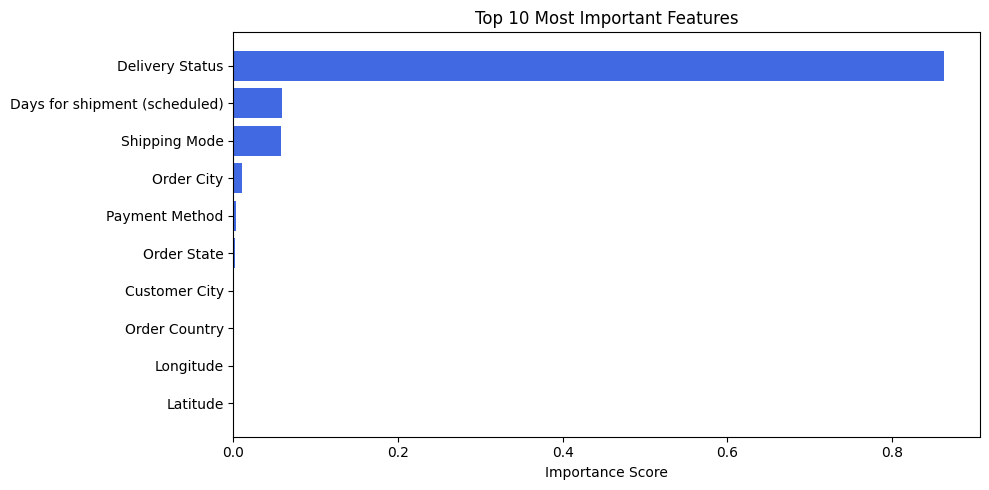

In [142]:
import pandas as pd
import matplotlib.pyplot as plt

importances = final_model.feature_importances_
features = x_train.columns

fi_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print("--- FEATURE IMPORTANCES ---")
print(fi_df.head(10))

# 4. Plot the importances
plt.figure(figsize=(10, 5))
plt.barh(fi_df['Feature'].head(10), fi_df['Importance'].head(10), color='royalblue')
plt.gca().invert_yaxis()
plt.title("Top 10 Most Important Features")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

In [ ]:
import joblib

# Save the trained machine learning model
joblib.dump(final_model, 'late_delivery_model.pkl')
print("Model saved successfully as 'late_delivery_model.pkl'!")

# Save the target encoder
joblib.dump(encoder, 'target_encoder.pkl')
print("Target encoder saved successfully as 'target_encoder.pkl'!")
